CSV path: /Users/iandownie/Documents/STM32/GNSSBuoyV2/rotation_test_values.csv


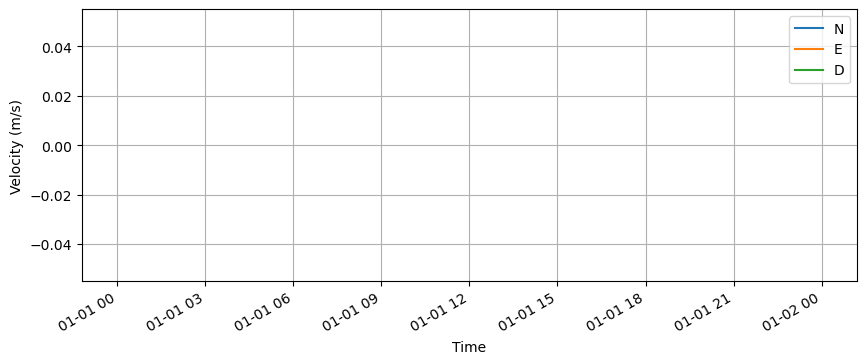

Connected: True
Listening... (Ctrl+C to stop)


In [ ]:
# Live BLE plotter with time axis (Jupyter-friendly)
import asyncio
import csv
import datetime
import os
from bleak import BleakClient

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, clear_output
import collections

# ---------------- CONFIG ----------------
ADDRESS = "12764788-CC99-3A0B-1607-43255AC43AC0"   # Replace with your UUID
CHAR_UUID = "0000FFE1-0000-1000-8000-00805F9B34FB"
CSV_FILENAME = "rotation_test_values.csv"

MAX_POINTS = 300      # visible window size
PLOT_REFRESH_S = 0.12 # how often the plot updates
# ----------------------------------------

# Rolling buffers
times = collections.deque(maxlen=MAX_POINTS)
v1 = collections.deque(maxlen=MAX_POINTS)
v2 = collections.deque(maxlen=MAX_POINTS)
v3 = collections.deque(maxlen=MAX_POINTS)


async def main():
    print("CSV path:", os.path.abspath(CSV_FILENAME))

    # ---- FIGURE SETUP --------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 4))

    line1, = ax.plot([], [], label="N")
    line2, = ax.plot([], [], label="E")
    line3, = ax.plot([], [], label="D")

    ax.set_xlabel("Time")
    ax.set_ylabel("Velocity (m/s)")
    ax.grid(True)
    ax.legend()

    # Time axis formatting
    locator = mdates.AutoDateLocator(minticks=3, maxticks=10)
    formatter = mdates.AutoDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    fig.autofmt_xdate()

    display(fig)

    # ---------------------------------------------------------------------

    def update_plot():
        """Refresh the live plot in Jupyter."""
        if len(times) == 0:
            return

        x = list(times)

        line1.set_data(x, list(v1))
        line2.set_data(x, list(v2))
        line3.set_data(x, list(v3))

        ax.relim()
        ax.autoscale_view()

        # force redraw in Jupyter
        clear_output(wait=True)
        display(fig)

    async def plot_task():
        while True:
            update_plot()
            await asyncio.sleep(PLOT_REFRESH_S)

    # BLE + CSV logging task
    async def ble_task():
        with open(CSV_FILENAME, "a", newline="") as csv_file:
            writer = csv.writer(csv_file)

            # Write CSV header if empty
            if csv_file.tell() == 0:
                writer.writerow(["Timestamp", "Val1", "Val2", "Val3"])
                csv_file.flush()

            def handle_data(sender, data):
                text = data.decode(errors="ignore").strip()
                timestamp = datetime.datetime.now()

                parts = [p.strip() for p in text.split(",")]

                if len(parts) != 3:
                    print("Invalid data:", text)
                    return

                try:
                    v1_val =  float(parts[0])/1000
                    print(v1_val)
                    v2_val =  float(parts[1])/1000
                    v3_val = float(parts[2])/1000
                except ValueError:
                    print("Non-numeric:", parts)
                    return

                # CSV
                writer.writerow([timestamp.isoformat(timespec='seconds'),
                                 v1_val, v2_val, v3_val])
                csv_file.flush()

                # Live buffers
                times.append(timestamp)
                v1.append(v1_val)
                v2.append(v2_val)
                v3.append(v3_val)

                print(timestamp.time(), parts)

            async with BleakClient(ADDRESS) as client:
                print("Connected:", client.is_connected)
                await client.start_notify(CHAR_UUID, handle_data)
                print("Listening... (Ctrl+C to stop)")

                try:
                    while True:
                        await asyncio.sleep(1)
                except asyncio.CancelledError:
                    pass
                finally:
                    await client.stop_notify(CHAR_UUID)
                    print("BLE notifications stopped.")

    # Run both tasks simultaneously
    plot_t = asyncio.create_task(plot_task())
    ble_t = asyncio.create_task(ble_task())

    try:
        await ble_t
    except KeyboardInterrupt:
        print("Stopping...")
    finally:
        plot_t.cancel()
        ble_t.cancel()
        await asyncio.gather(plot_t, ble_t, return_exceptions=True)
        print("Done. CSV saved:", os.path.abspath(CSV_FILENAME))


# ------- Run in Jupyter --------
try:
    loop = asyncio.get_running_loop()
    await main()
except RuntimeError:
    asyncio.run(main())
